<img src="https://spire.com/wp-content/themes/spire2021/img/spire-global-cubesat-satellite-logo.svg" width="170" alt="Spire">

# Spire AI-S2S on Earthmover

| Author |
| --- |
| Spire Weather & Climate · AI-S2S team |


---


## Overview

This notebook shows how to **open and use** the Spire AI-S2S hindcast (the full 2026 record, **220+ issuances** to date, from January 1 through 30 days prior to today) from Arraylake — from one
`xr.open_zarr` call to a full energy desk view: *temperature*, *500 hPa pattern*, *weather
regime* probabilities, *point fans*, and *ISO area means* for **North America**. Everything below is driven by data opened straight from the Arraylake catalog repo
`Spire/saifs-s2s-hindcast`.

### What's in this notebook

1. **Open the dataset** — five zarr groups, latest init, one cell each.
2. **500 hPa wks 1–6** — anomaly fill + absolute height contours over *North America*.
3. **T-max wks 1–6** — anomaly fill over *North America*.
4. **Weather regimes** — daily probability bars for the *CONUS* regime set, straight from the `regimes` group.
5. **Load center fans** — ensemble fans with percentile bands at four North American hubs.
6. **ISO area-mean** — PJM, MISO, ERCOT, NYISO daily T-max anomaly curves over the full horizon.


---


## Prerequisites

| Concepts | Importance | Notes |
| --- | --- | --- |
| [Xarray fundamentals](https://docs.xarray.dev/en/stable/getting-started-guide/quick-overview.html) | Necessary | `DataArray`, coords, `.sel` |
| [Arraylake + zarr v3](https://docs.earthmover.io/) | Necessary | how the data is served |
| [matplotlib](https://matplotlib.org/) | Helpful | every plot below is `matplotlib` (+ `cartopy` for maps) |

- **Time to learn**: ~10 minutes
- **Run it**: this notebook is **Colab-ready** — open it in
  [Google Colab](https://colab.research.google.com/), run the first **setup cell** (installs deps
  and runs `arraylake auth login`), then run top to bottom.
- **Prework** (local kernel, optional):
    - `uv sync` &nbsp;— resolve and install the project environment from `pyproject.toml` / `uv.lock`.
    - `uv run python -m ipykernel install --user --name ai-s2s-webinar` &nbsp;— register the kernel this notebook expects.
    - `arraylake auth login` &nbsp;— authenticate to the Arraylake catalog (no AWS credentials needed).


---


## Imports


In [13]:
# --- Colab setup: install deps + authenticate to Arraylake ---
# (Safe to re-run; skip this cell on a local uv-managed kernel.)
# If cartopy fails to import below, uncomment the apt line first.
# !apt-get -qq install -y libgeos-dev libproj-dev proj-bin
%pip install -q arraylake xarray "zarr>=3" dask numpy pandas \
    matplotlib cartopy regionmask shapely



/Users/maxwellgrover/git_repos/spire-earthmover-demo/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


## Log into Earthmover
You will need to log into your Earthmover Account (https://www.earthmover.io/) and authenticate in this cell.

In [2]:
from arraylake import Client

client = Client()
client.login()

Successfully refreshed tokens! Token stored at /Users/maxwellgrover/.arraylake/token.json

╭───────────────────────────────────────────────── User Details ──────────────────────────────────────────────────╮
│ Name: None None                                                                                                 │
│ Email: maxwell.grover@spire.com                                                                                 │
│ Id: c4434dbc-e8d2-4485-8871-50001ed1dbd4                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## Imports

In [3]:
import arraylake
import xarray as xr
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.path as mpath
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import regionmask
from shapely.geometry import box

plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 11, 'font.size': 9})


---


## Open the AI-S2S hindcast from Arraylake

Spire AI-S2S hindcasts are published to the Arraylake catalog as the repo
**`Spire/saifs-s2s-hindcast`**. Quick orientation so the rest of the notebook makes sense.

### What's in the dataset

- **Forecast** — 200 ensemble members, **46-day** lead (day 1 → day 46), *daily resolved*.
- **Spatial** — **0.5° global** grid: 361 latitudes × 720 longitudes; longitudes are `[0, 359.5]`.
- **Vertical** — 4 isobaric levels for upper-air variables: **200 / 500 / 850 / 1000 hPa**.
- **Layout** — split into **five zarr groups**, each on the same
  `(reference_time, step, latitude, longitude)` grid for the GRIB groups, plus a compact
  `regimes` group keyed by `(reference_time, step, regime)`:

| Group | What's inside |
| :--- | :--- |
| **`mean_stddev`**   | ensemble *mean* and *standard deviation* — temperature, wind, precipitation, pressure, radiation, geopotential height, specific humidity |
| **`percentiles`**   | `<var>_pctl` at `[1, 5, 10, 20, 50, 80, 90, 95, 99]` across the 200 members |
| **`probabilities`** | probability of falling in climatological *terciles / quintiles / deciles* and above-normal vs ERA5 1991–2020 |
| **`anomalies`**     | *departures* from the ERA5 1991–2020 climatological mean |
| **`regimes`**       | CONUS (5) and EUATL (8) weather-regime probabilities — `(reference_time, step, regime)` |

### How it's stored

- **Icechunk** repository backed by **zarr v3**, served through the **Arraylake** catalog — a
  transactional, branchable storage layer for analysis-ready scientific data.
- Every GRIB variable is chunked `(1, 1, 361, 720)` along `(reference_time, step, lat, lon)` —
  so *a single global map at one init + one lead is **one chunk = one read***.
- **Full record, preallocated** — the store has **1096 `reference_time` slots** (three years of daily
  inits) and currently holds **221 valid issuances**, 2026-01-01 → 2026-08-09. Slots are written as inits
  arrive, so the on-disk order is *not* chronological — always `sortby('reference_time')` — and unused
  slots are NaT-filled, so pick the latest *non-NaT* `reference_time`.
- **Real-time sibling** — `Spire/saifs-s2s-daily` carries the same layout as a 15-issuance rolling window;
  everything below works unchanged against it.
- The store is opened through the **Arraylake** client (`arraylake.Client().get_repo(...)`) —
  authenticate once with `arraylake auth login`; no AWS credentials needed.

### The open recipe

One `xr.open_zarr` call per group, against the read-only `main` branch session — that's it.


In [4]:
# 1.  Open the hindcast via the Arraylake catalog (auth from `arraylake auth login`).
client = arraylake.Client()
repo   = client.get_repo("Spire/saifs-s2s-hindcast")
ro     = repo.readonly_session(branch="main")

# 2.  Open each zarr group as an xarray.Dataset.
def open_group(group):
    return xr.open_zarr(ro.store, group=group, zarr_format=3).sortby('reference_time')

mean    = open_group('mean_stddev')
pctl    = open_group('percentiles')
prob    = open_group('probabilities')
anom    = open_group('anomalies')
regimes = open_group("regimes")

# 3.  Pick the latest non-NaT issuance (rolling-window slots are NaT-filled).
rt          = pd.to_datetime(anom.reference_time.values)
VALID_INITS = rt[~pd.isna(rt)].sort_values()
INIT_TS     = VALID_INITS[-1]
INIT        = INIT_TS.strftime('%Y-%m-%d')
STEPS = (mean.step.values.astype(int)
         if mean.step.dtype.kind in 'iu'
         else (mean.step / np.timedelta64(1, 'D')).astype(int).values)

# 4.  Quick shape summary across all 5 groups.
print(f'Valid inits : {len(VALID_INITS)}  ({VALID_INITS[0]:%Y-%m-%d} → {VALID_INITS[-1]:%Y-%m-%d}; '
      f'{anom.sizes["reference_time"]} slots allocated)')
print(f'Latest init : {INIT}')
print(f'Lead horizon: day {STEPS[0]} → day {STEPS[-1]}  (daily)')
print(f'Grid        : {mean.sizes["latitude"]} × {mean.sizes["longitude"]}  @ 0.5°\n')
for name, ds in [('mean_stddev',  mean),
                 ('percentiles',  pctl),
                 ('probabilities', prob),
                 ('anomalies',    anom),
                 ('regimes',      regimes)]:
    print(f'  {name:14s}  vars={len(ds.data_vars):3d}   dims={dict(ds.sizes)}')


  2026-09-10T18:33:45.903782Z  WARN aws_runtime::env_config::normalize: profile `[default]` ignored because `[profile default]` was found which takes priority
    at /Users/runner/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-runtime-1.7.2/src/env_config/normalize.rs:136

Valid inits : 223  (2026-01-01 → 2026-08-11; 1096 slots allocated)
Latest init : 2026-08-11
Lead horizon: day 1 → day 46  (daily)
Grid        : 361 × 720  @ 0.5°

  mean_stddev     vars= 36   dims={'reference_time': 1096, 'step': 46, 'latitude': 361, 'longitude': 720, 'isobar': 2}
  percentiles     vars= 13   dims={'reference_time': 1096, 'step': 46, 'percentile': 9, 'latitude': 361, 'longitude': 720}
  probabilities   vars= 84   dims={'reference_time': 1096, 'step': 46, 'latitude': 361, 'longitude': 720}
  anomalies       vars= 10   dims={'reference_time': 1096, 'step': 46, 'latitude': 361, 'longitude': 720, 'isobar': 2}
  regimes         vars=  2   dims={'reference_time': 1096, 'step': 46, 'euatl_regime':

### Peek at one variable

Pick one variable (2-m mean temperature) at the **latest init** and let xarray show its
structure: `(step, latitude, longitude) = (46, 361, 720)`, with **dask chunks of
`(1, 361, 720)`** — one global map per chunk. Nothing has actually been read from S3 yet; the
data only loads when you call `.values`, `.load()`, or render a plot.


In [5]:
mean['air_temperature'].sel(reference_time=INIT)


<xarray.DataArray 'air_temperature' (step: 46, latitude: 361, longitude: 720)> Size: 48MB
dask.array<getitem, shape=(46, 361, 720), dtype=float32, chunksize=(1, 361, 720), chunktype=numpy.ndarray>
Coordinates:
  * step            (step) timedelta64[D] 368B 1 days 2 days ... 45 days 46 days
  * latitude        (latitude) float64 3kB 90.0 89.5 89.0 ... -89.0 -89.5 -90.0
  * longitude       (longitude) float64 6kB 0.0 0.5 1.0 ... 358.5 359.0 359.5
    reference_time  datetime64[ns] 8B 2026-08-11
Attributes:
    standard_name:  air_temperature
    units:          K
    long_name:      2m air temperature
    description:    Air temperature at 2 metres above the surface. 24-hour en...

---


## Small helpers

Unit conversion, longitude wrap, weekly lead-day buckets (**six** of them — wk 1 … wk 6), and a
a map base for **North America**.


In [6]:
K_to_F      = lambda K: (K - 273.15) * 9 / 5 + 32
K_to_F_anom = lambda K: K * 9 / 5

def to_180(da):
    return da.assign_coords(longitude=(((da.longitude + 180) % 360) - 180)).sortby('longitude')

def area_mean(da, mask, rid):
    w = np.cos(np.deg2rad(da.latitude))
    return da.where(mask == rid).weighted(w).mean(('latitude', 'longitude'))

def sym(da, q=98):
    v = float(np.nanpercentile(np.abs(da.values), q));  return (-v, v)

# Six-week buckets — wk 1 … wk 6, seven days each.
WEEKS = {f'Wk {w}': np.where((STEPS >= 1 + 7*(w-1)) & (STEPS <= 7*w))[0]
         for w in range(1, 7)}

# Region domain — North America (EU kept for reference; SP is a south-pole diagnostic).
# SP uses SouthPolarStereo so zonal-stripe artifacts read as concentric rings, not as the
# heavily-distorted horizontal smears that PlateCarree produces near the pole.
NA = dict(lat=( 8, 82), lon=(-170, -45))
EU = dict(lat=(20, 82), lon=(-40,  55))
SP = dict(lat=(-90, -50), lon=(-180, 180), projection=ccrs.SouthPolarStereo())

def setup_geoax(ax, region):
    proj = region.get('projection', ccrs.PlateCarree())
    ax.coastlines('50m', linewidth=0.5)
    ax.add_feature(cfeature.BORDERS.with_scale('50m'), linewidth=0.4)
    ax.add_feature(cfeature.STATES.with_scale('50m'), linewidth=0.3, edgecolor='gray')
    if isinstance(proj, ccrs.PlateCarree):
        ax.set_extent([*region['lon'], *region['lat']], crs=ccrs.PlateCarree())
    else:
        # Polar cap: clip to the latitude band and draw a circular boundary.
        ax.set_extent([-180, 180, region['lat'][0], region['lat'][1]], crs=ccrs.PlateCarree())
        theta = np.linspace(0, 2 * np.pi, 100)
        verts = np.vstack([np.sin(theta), np.cos(theta)]).T
        ax.set_boundary(mpath.Path(verts * 0.5 + 0.5), transform=ax.transAxes)

def region_slice(da, region):
    return (to_180(da).sel(latitude=slice(region['lat'][1], region['lat'][0]),
                             longitude=slice(*region['lon'])))


---


## North America · 500 hPa pattern, wks 1–6

**Start at the steering level.**

- **Fill** — *500 hPa height anomaly* &nbsp;·&nbsp; `anomalies` group &nbsp;·&nbsp; m
- **Black contours** — *absolute 500 hPa height* &nbsp;·&nbsp; `mean_stddev` group &nbsp;·&nbsp; every 60 m

*Ridges and troughs* **pop out immediately** — and the **contour spacing** tells you how strong
the gradient (i.e. the jet) is on top of them. Each panel is the **7-day mean** over the
corresponding forecast week, all panels on a *shared symmetric color scale* so weeks compare
directly.


In [7]:
def z_maps(region, region_name):
    abs_all  = region_slice(
        mean.geopotential_height_at_isobaric_levels.sel(reference_time=INIT, isobar=50000),
        region).load()
    anom_all = region_slice(
        anom.geopotential_height.sel(reference_time=INIT, isobar=50000),
        region).load()
    clim = sym(anom_all)
    proj = region.get('projection', ccrs.PlateCarree())
    fig, axes = plt.subplots(2, 3, figsize=(15, 8), layout='constrained',
                             subplot_kw={'projection': proj})
    for ax, (week_label, idx) in zip(axes.flat, WEEKS.items()):
        abs_w  = abs_all .isel(step=idx).mean('step')
        anom_w = anom_all.isel(step=idx).mean('step')
        lo = int(np.floor(float(abs_w.min()) / 60) * 60)
        hi = int(np.ceil (float(abs_w.max()) / 60) * 60)
        lon, lat = anom_w.longitude.values, anom_w.latitude.values
        mesh = ax.pcolormesh(lon, lat, anom_w.values, transform=ccrs.PlateCarree(),
                             cmap='RdBu_r', vmin=clim[0], vmax=clim[1], shading='auto')
        ax.contour(lon, lat, abs_w.values, levels=range(lo, hi + 1, 60),
                   colors='black', linewidths=0.8, transform=ccrs.PlateCarree())
        setup_geoax(ax, region)
        ax.set_title(f'{region_name} · {week_label}')
    fig.colorbar(mesh, ax=axes, orientation='horizontal', shrink=0.6, pad=0.03,
                 label='z500 anomaly (m)')
    return fig


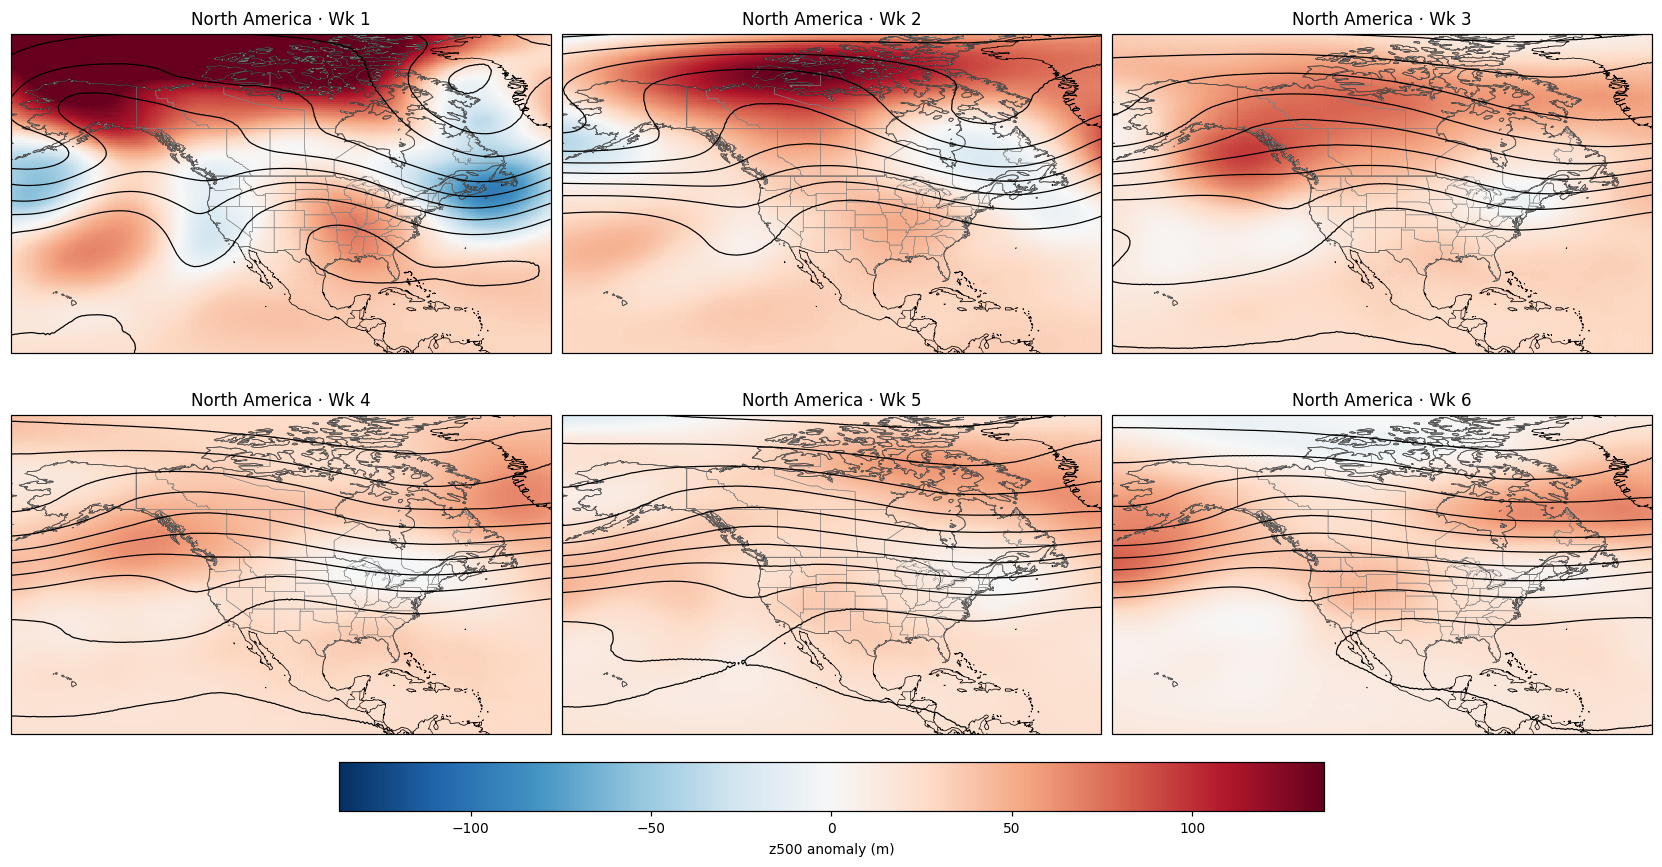

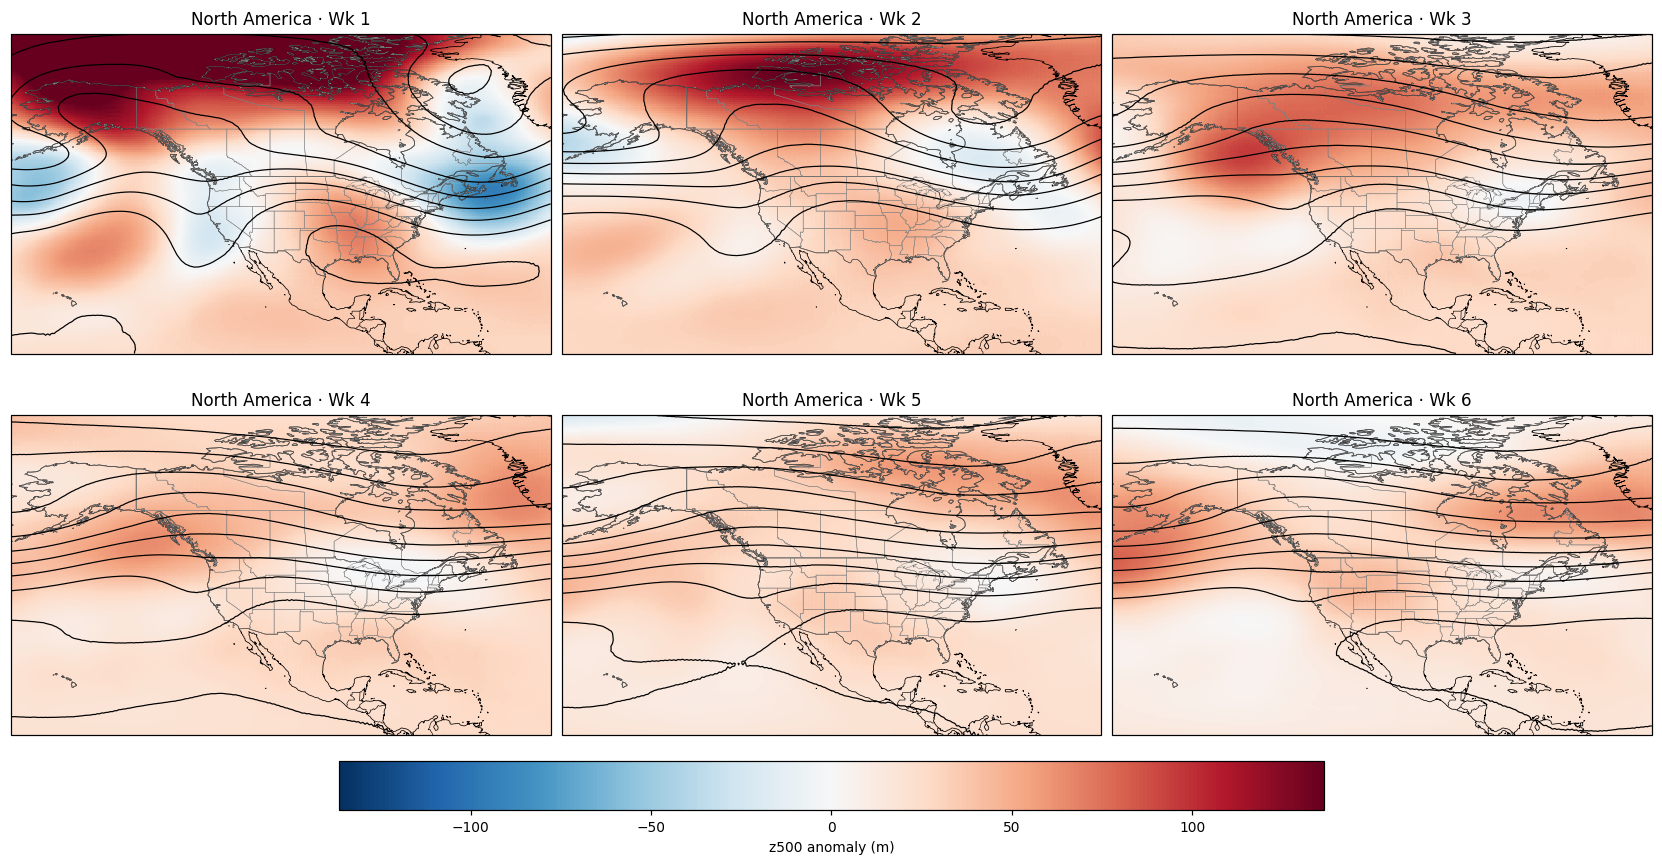

In [8]:
z_maps(NA, 'North America')

---


## North America · daily T-max anomaly, wks 1–6

**One field, six panels.**

- **Fill** — T-max **anomaly** &nbsp;·&nbsp; `anomalies` group &nbsp;·&nbsp; *°F vs ERA5 1991–2020*

Each panel is the **7-day mean** over the corresponding forecast week. *Anomaly colors share a
common symmetric scale across all panels* so weeks are directly comparable.


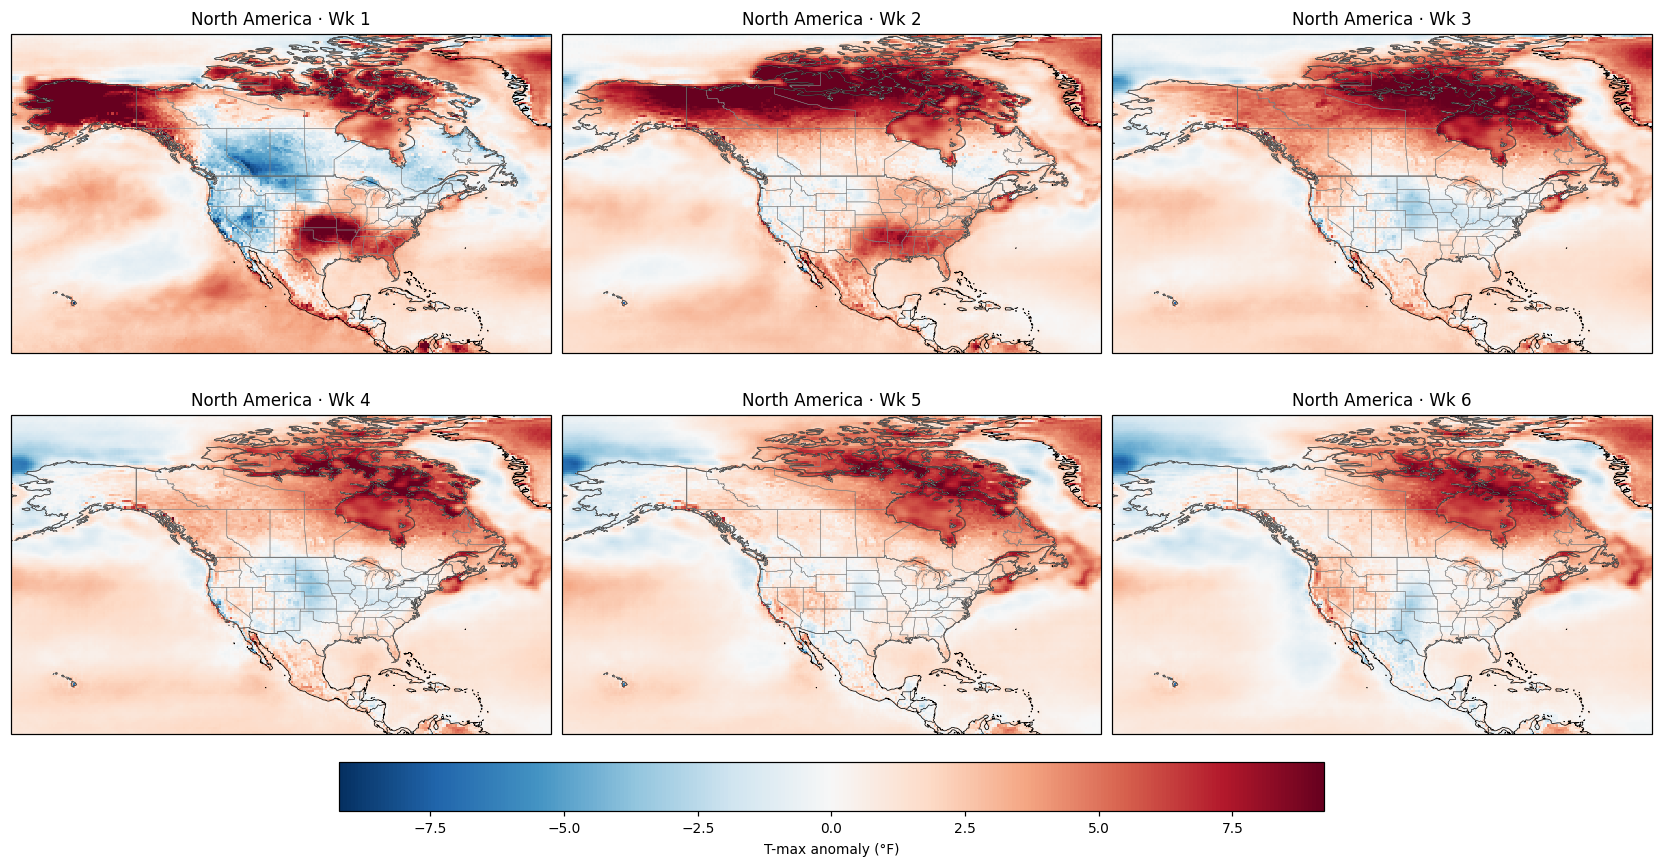

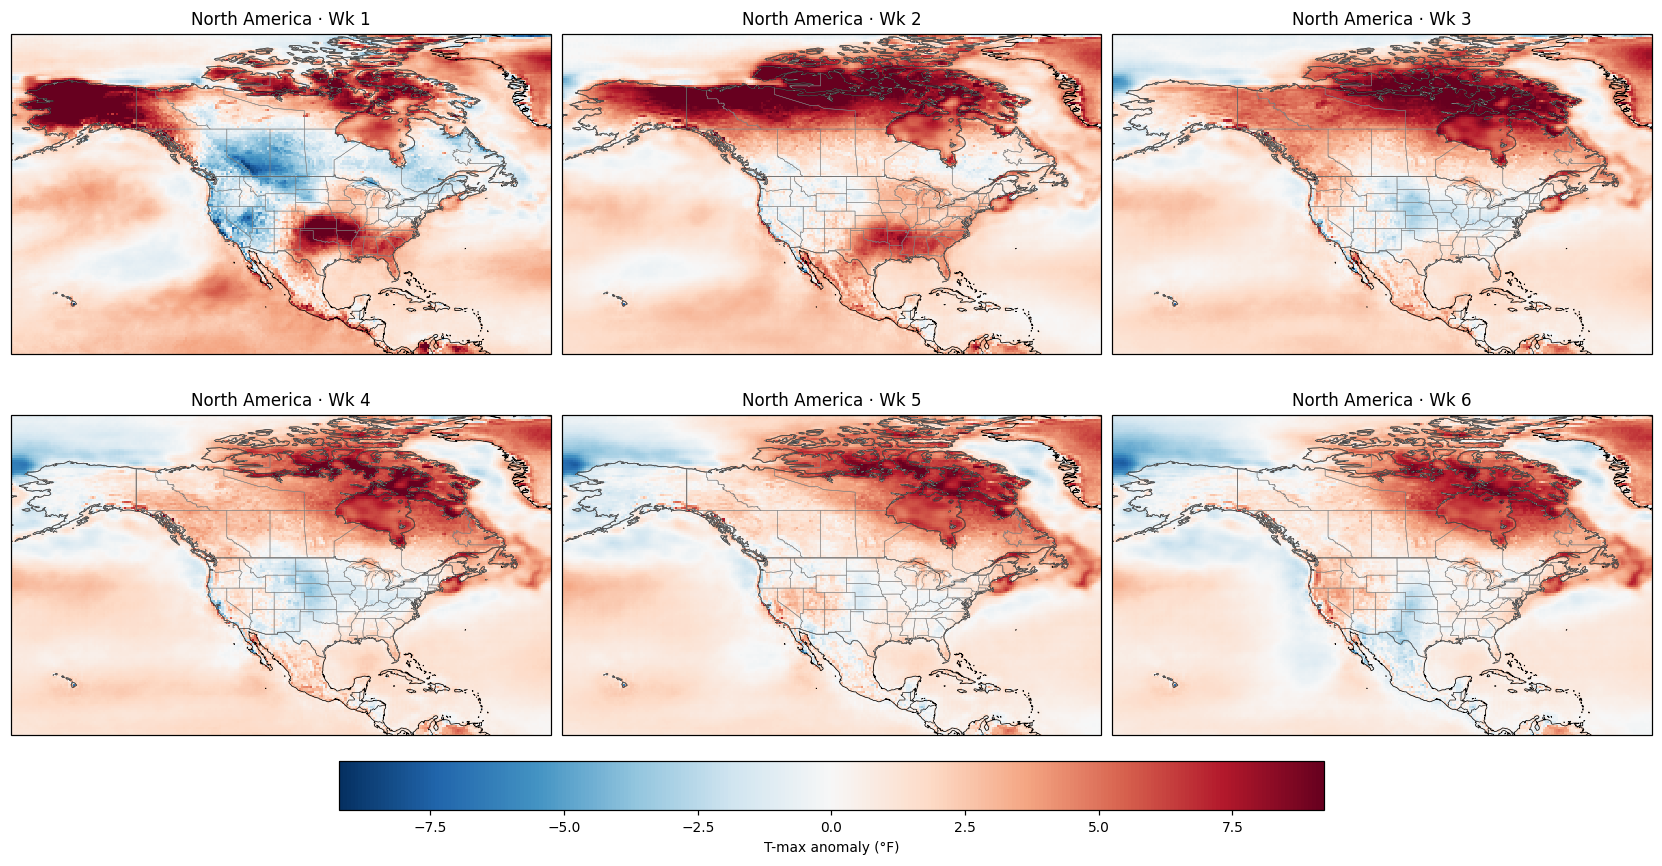

In [9]:
def t_maps(region, region_name):
    anom_all = K_to_F_anom(region_slice(anom.air_temperature_max.sel(reference_time=INIT), region)).load()
    clim = sym(anom_all)
    proj = region.get('projection', ccrs.PlateCarree())
    fig, axes = plt.subplots(2, 3, figsize=(15, 8), layout='constrained',
                             subplot_kw={'projection': proj})
    for ax, (week_label, idx) in zip(axes.flat, WEEKS.items()):
        anom_w = anom_all.isel(step=idx).mean('step')
        lon, lat = anom_w.longitude.values, anom_w.latitude.values
        mesh = ax.pcolormesh(lon, lat, anom_w.values, transform=ccrs.PlateCarree(),
                             cmap='RdBu_r', vmin=clim[0], vmax=clim[1], shading='auto')
        setup_geoax(ax, region)
        ax.set_title(f'{region_name} · {week_label}')
    fig.colorbar(mesh, ax=axes, orientation='horizontal', shrink=0.6, pad=0.03,
                 label='T-max anomaly (°F)')
    return fig

t_maps(NA, 'North America')


---


## Weather regime probabilities — CONUS

*Weather regimes* are a handful of canonical 500 hPa patterns — they organise temperature, wind
and precip anomalies across a region. Below is the regime probability evolution for **CONUS** (5 regimes).

> The `regimes` group is populated for a subset of issuances (it currently stops at 2026-07-24 while the
> gridded groups run to 2026-08-09), so this section picks the **latest init that has regime data** rather
> than `INIT`. Each **day** is
a stacked bar summing to 100 % across regimes — same style as the
[Simon Lee GEFS regime plots](https://simonleewx.com/gefs_north_america_regimes/).


regime data available for 143 of 223 inits; plotting 2026-08-11


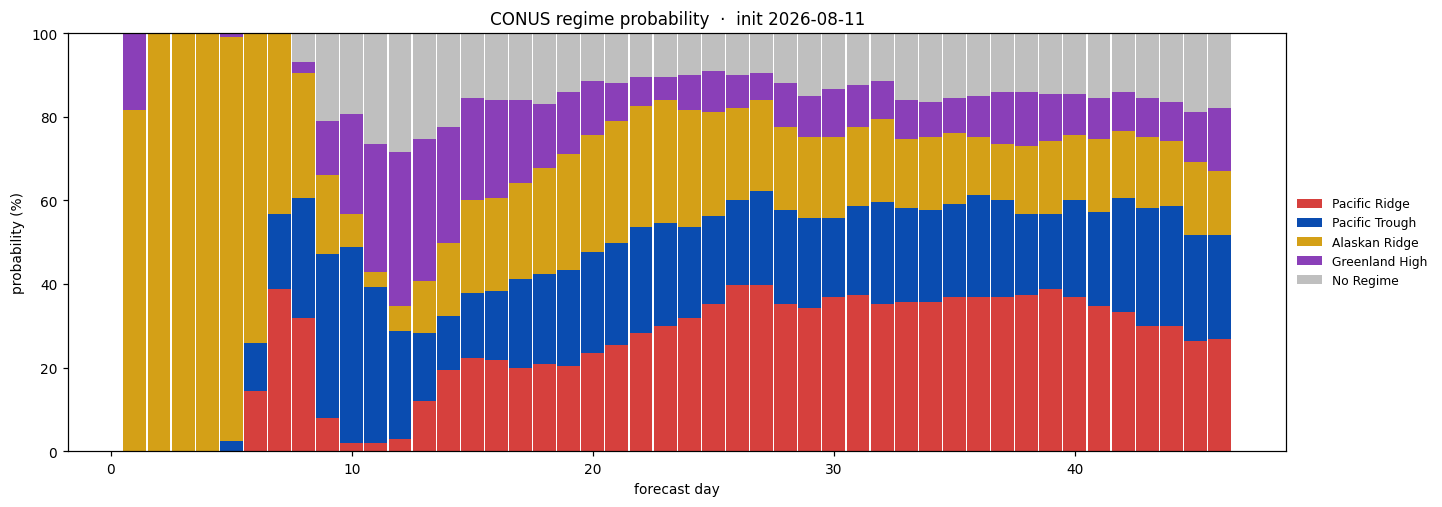

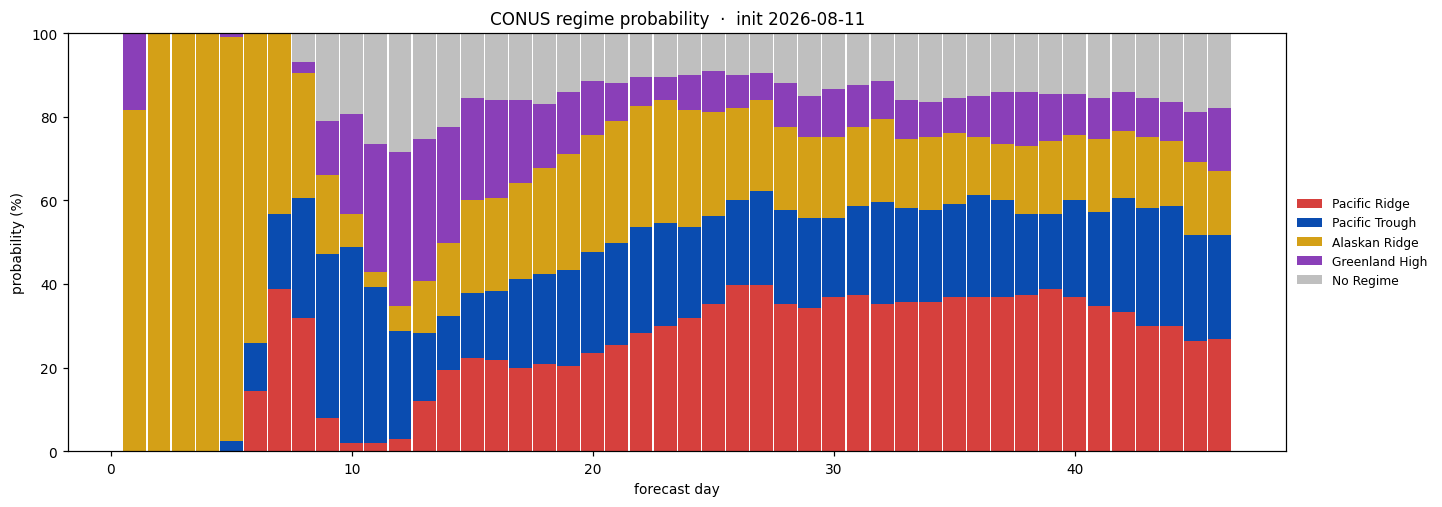

In [10]:
CONUS_ORDER = ['Pacific Ridge', 'Pacific Trough', 'Alaskan Ridge',
                'Greenland High', 'No Regime']
CONUS_COLORS = ['#d6403d', '#0a4cb0', '#d4a017', '#8a3fb8', '#bfbfbf']

def regime_plot(ax, da, regime_dim, order, colors, title):
    # da: (step, regime) probabilities in [0, 1] for one reference_time.
    df = da.reindex({regime_dim: order}).to_pandas().multiply(100.0)   # 0..1 -> 0..100 %
    bottom = np.zeros(len(STEPS))
    for col, color in zip(order, colors):
        ax.bar(STEPS, df[col].values, bottom=bottom, color=color,
               width=0.95, label=col, linewidth=0)
        bottom += df[col].values
    ax.set_ylim(0, 100)
    ax.set_xlabel('forecast day'); ax.set_ylabel('probability (%)')
    ax.set_title(title)
    ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=8, frameon=False)

# Latest issuance with regime data (the group is NaN-filled where the regime step did not run).
_first = regimes.conus.isel(step=0).load()
_has   = (~np.isnan(_first).all('conus_regime')).values & ~pd.isna(pd.to_datetime(regimes.reference_time.values))
_pos   = int(np.where(_has)[0][-1])
REGIME_INIT = pd.Timestamp(regimes.reference_time.values[_pos]).strftime('%Y-%m-%d')
print(f'regime data available for {int(_has.sum())} of {len(VALID_INITS)} inits; plotting {REGIME_INIT}')

conus_da = regimes.conus.isel(reference_time=_pos)

fig, ax1 = plt.subplots(figsize=(13, 4.5), layout='constrained')
regime_plot(ax1, conus_da, 'conus_regime', CONUS_ORDER, CONUS_COLORS,
            f'CONUS regime probability  ·  init {REGIME_INIT}')
fig


---


## Major load centers — daily T-max **ensemble fan**

**All 200 members at a point**, summarized by the **`percentiles`** group.

- **Nested bands** — *1–99 %* / *5–95 %* / *10–90 %* / *20–80 %*
- **Solid line** — ensemble mean (from `mean_stddev`)
- **Dotted line** — median (from `percentiles`)

*Four North American hubs — the desk's day-to-day demand watchpoints.*


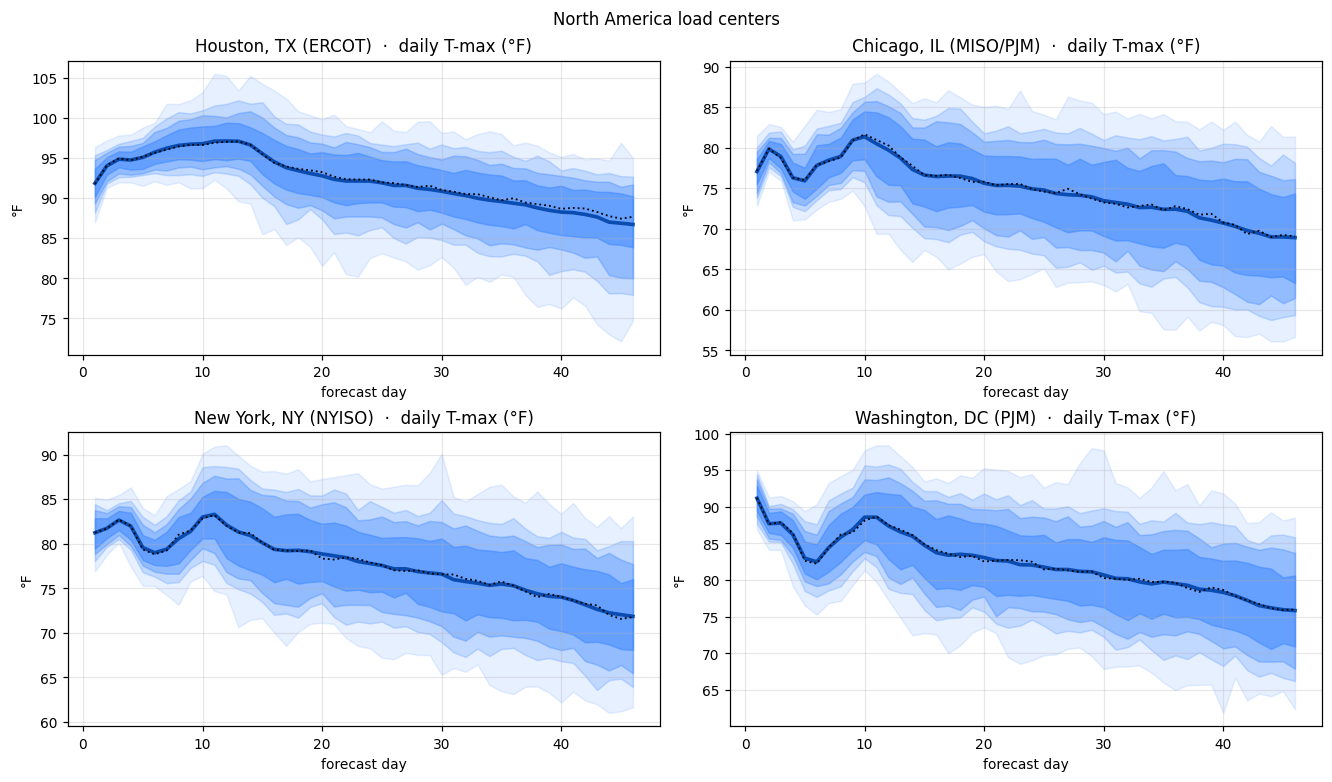

In [11]:
HUBS_NA = {
    'Houston, TX (ERCOT)'    : (29.76, -95.37),
    'Chicago, IL (MISO/PJM)' : (41.85, -87.65),
    'New York, NY (NYISO)'   : (40.71, -74.00),
    'Washington, DC (PJM)'   : (38.91, -77.04),
}
def fan(ax, name, lat, lon):
    lon360 = lon % 360
    # Select reference_time exactly first (the hindcast store's reference_time
    # coord includes NaT-filled slots, which makes a combined .sel(..., method='nearest')
    # reindex blow up — split it.
    p = K_to_F(pctl.air_temperature_max_pctl
                  .sel(reference_time=INIT)
                  .sel(latitude=lat, longitude=lon360, method='nearest')).load()
    m = K_to_F(mean.air_temperature_max
                  .sel(reference_time=INIT)
                  .sel(latitude=lat, longitude=lon360, method='nearest')).load()
    for lo, hi, a, lbl in [(1, 99, 0.12, '1–99 %'),
                           (5, 95, 0.22, '5–95 %'),
                           (10, 90, 0.34, '10–90 %'),
                           (20, 80, 0.50, '20–80 %')]:
        ax.fill_between(STEPS, p.sel(percentile=lo).values, p.sel(percentile=hi).values,
                        color='#3a86ff', alpha=a, label=lbl)
    ax.plot(STEPS, m.values, color='#0a4cb0', lw=2.4, label='ens-mean')
    ax.plot(STEPS, p.sel(percentile=50).values, color='k', lw=1.2, ls=':', label='median')
    ax.set_title(f'{name}  ·  daily T-max (°F)')
    ax.set_xlabel('forecast day'); ax.set_ylabel('°F')
    ax.grid(True, alpha=0.3)

def fan_grid(hubs, suptitle):
    fig, axes = plt.subplots(2, 2, figsize=(12, 7), layout='constrained')
    for ax, (n, (lat, lon)) in zip(axes.flat, hubs.items()):
        fan(ax, n, lat, lon)
    fig.suptitle(suptitle)
    return fig

fan_grid(HUBS_NA, 'North America load centers');


---


## U.S. ISOs — area-mean daily T-max **anomaly** over the full horizon

*Cosine-weighted* area mean of the **`anomalies`** T-max field for the four major U.S. power
markets — **all on one chart**.

> **Zero line = ERA5 1991–2020 climatology.**

Excursions above / below are *the load story*: **warm** departures in PJM and MISO drive cooling
demand; **cold** departures in NYISO drive heating demand.


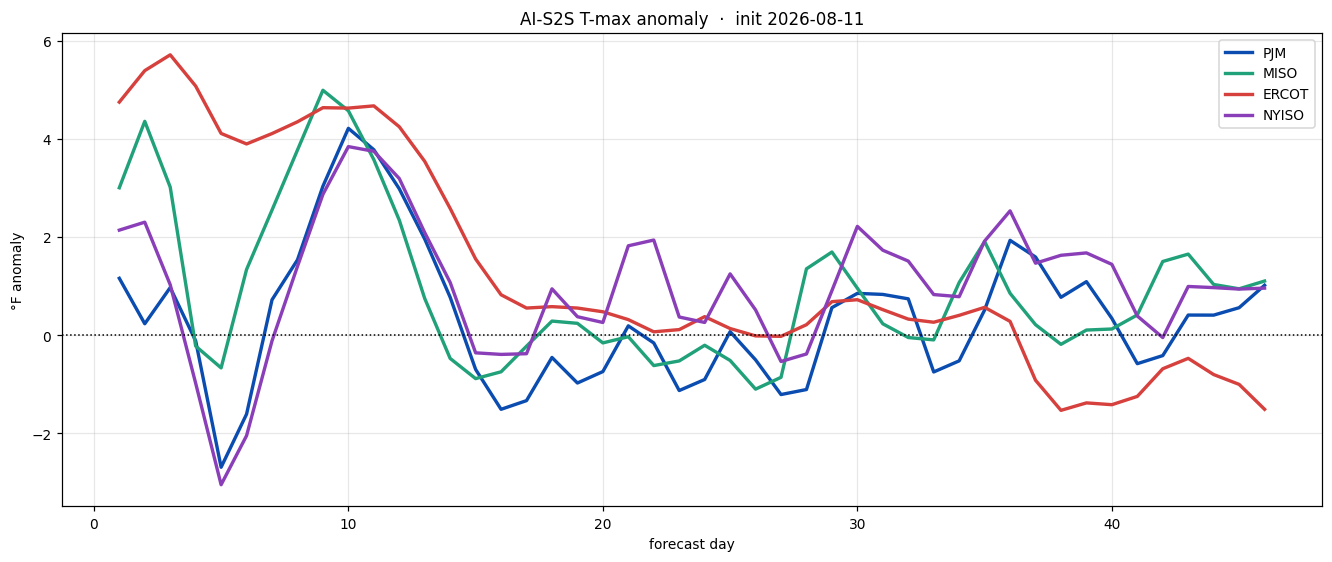

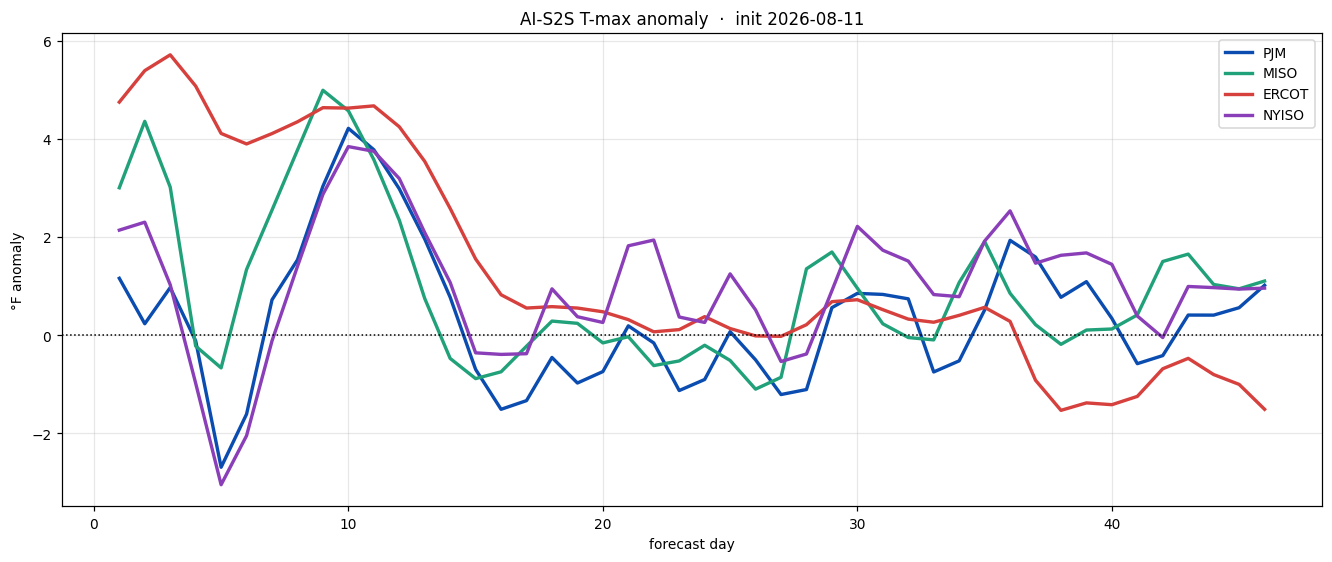

In [12]:
ISOS = regionmask.Regions(
    outlines=[
        box(-82,   38, -76.5, 42),    # PJM (Mid-Atlantic core)
        box(-97,   38, -82,   49),    # MISO (Midwest)
        box(-107,  25, -93,   37),    # ERCOT (Texas)
        box(-76,   40, -71,   45),    # NYISO
    ],
    names  =['PJM', 'MISO', 'ERCOT', 'NYISO'],
    abbrevs=['PJM', 'MISO', 'ERCOT', 'NYISO'],
    name='U.S. ISOs',
)

a_F = K_to_F_anom(to_180(anom.air_temperature_max.sel(reference_time=INIT))
                      .sel(latitude=slice(60, 22))).load()
mask = ISOS.mask(a_F.longitude, a_F.latitude)

COLORS = {'PJM': '#0a4cb0', 'MISO': '#21a179', 'ERCOT': '#d6403d', 'NYISO': '#8a3fb8'}

fig, ax = plt.subplots(figsize=(12, 5), layout='constrained')
for iso in ['PJM', 'MISO', 'ERCOT', 'NYISO']:
    rid = ISOS.map_keys(iso)
    y   = area_mean(a_F, mask, rid).values
    ax.plot(STEPS, y, color=COLORS[iso], lw=2.2, label=iso)
ax.axhline(0, color='k', ls=':', lw=1)
ax.set_title(f'AI-S2S T-max anomaly  ·  init {INIT}')
ax.set_xlabel('forecast day'); ax.set_ylabel('°F anomaly')
ax.legend(loc='upper right'); ax.grid(True, alpha=0.3)
fig


---


## Summary

Five `xr.open_zarr` calls on Arraylake and the full energy desk view falls out: **spatial
pattern**, **weather regimes**, **point fans**, **ISO area means** — for **North America**.

### Resources

- Earthmover marketplace — [app.earthmover.io/marketplace](https://app.earthmover.io/marketplace)
- Earthmover docs — [docs.earthmover.io](https://docs.earthmover.io/)
